In [3]:
import sys
!{sys.executable} -m pip install shap

In [4]:
# ============================================================
# TOURISM RISK & CONTEXT INTELLIGENCE SYSTEM
# ML Model Training Notebook — PP1 / Viva Evidence
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (mean_absolute_error, r2_score,
                             classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import LabelEncoder
import shap
import pickle
import json
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("✅ All libraries loaded successfully")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   shap       {shap.__version__}")

✅ All libraries loaded successfully
   pandas     2.3.2
   numpy      2.2.6
   shap       0.49.1


## Section 1 — Data Loading and Overview
Loading the master dataset and inspecting its shape, columns, and basic statistics.

In [10]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\tourism_risk_system\data\master_dataset.csv")

print(f"Total records : {len(df)}")
print(f"Total columns : {len(df.columns)}")
print(f"\nColumn list:")
for col in df.columns:
    print(f"  {col}  —  {df[col].dtype}")

Total records : 21930
Total columns : 27

Column list:
  date  —  object
  site_id  —  int64
  site_name  —  object
  district  —  object
  province  —  object
  category  —  object
  latitude  —  float64
  longitude  —  float64
  day_of_week  —  int64
  month  —  int64
  season  —  object
  is_weekend  —  int64
  is_public_holiday  —  int64
  is_festival_period  —  int64
  avg_temperature_c  —  int64
  avg_rainfall_mm  —  int64
  daily_flights_at_cmb  —  int64
  is_eco_friendly  —  int64
  is_unesco  —  int64
  entrance_fee_lkr  —  int64
  capacity_per_day  —  int64
  estimated_daily_visitors  —  int64
  crowd_score_normalized  —  float64
  risk_level  —  object
  district_encoded  —  int64
  category_encoded  —  int64
  season_encoded  —  int64


In [6]:
import os
print("Notebook is running from:", os.getcwd())

Notebook is running from: C:\Users\ASUS\OneDrive - Sri Lanka Institute of Information Technology\Desktop\tourism_risk_system


In [11]:
df.head(10)

,date,site_id,site_name,district,province,category,latitude,longitude,day_of_week,month,...,is_eco_friendly,is_unesco,entrance_fee_lkr,capacity_per_day,estimated_daily_visitors,crowd_score_normalized,risk_level,district_encoded,category_encoded,season_encoded
0,2024-01-01,1,Sigiriya Rock Fortress,Matale,Central,Heritage,7.9570,80.7603,0,1,...,0,1,3500,2500,2500,1.000,High,0,0,0
1,2024-01-01,2,Galle Fort,Galle,Southern,Heritage,6.0328,80.2168,0,1,...,0,1,0,4000,2404,0.601,Medium,1,0,0
2,2024-01-01,3,Temple of the Tooth Kandy,Kandy,Central,Religious,7.2936,80.6413,0,1,...,0,0,0,6000,3769,0.628,Medium,2,1,0
3,2024-01-01,4,Yala National Park,Hambantota,Southern,Nature,6.3728,81.5216,0,1,...,1,0,3000,1200,1200,1.000,High,3,2,0
4,2024-01-01,5,Mirissa Beach,Matara,Southern,Beach,5.9483,80.4716,0,1,...,1,0,0,5000,1057,0.211,Low,4,3,0
5,2024-01-01,6,Anuradhapura Sacred City,Anuradhapura,North Central,Heritage,8.3114,80.4037,0,1,...,0,1,500,4000,2168,0.542,Medium,5,0,0
6,2024-01-01,7,Ella Rock,Badulla,Uva,Nature,6.8667,81.0466,0,1,...,1,0,0,2000,977,0.488,Medium,6,2,0
7,2024-01-01,8,Nuwara Eliya,Nuwara Eliya,Central,Nature,6.9497,80.7891,0,1,...,1,0,0,6000,1222,0.204,Low,7,2,0
8,2024-01-01,9,Dambulla Cave Temple,Matale,Central,Religious,7.8568,80.6487,0,1,...,0,1,1500,4000,1896,0.474,Medium,0,1,0
9,2024-01-01,10,Horton Plains National Park,Nuwara Eliya,Central,Nature,6.8016,80.8044,0,1,...,1,0,1500,1000,734,0.734,Medium,7,2,0


In [12]:
df.describe()

,site_id,latitude,longitude,day_of_week,month,is_weekend,is_public_holiday,is_festival_period,avg_temperature_c,avg_rainfall_mm,daily_flights_at_cmb,is_eco_friendly,is_unesco,entrance_fee_lkr,capacity_per_day,estimated_daily_visitors,crowd_score_normalized,district_encoded,category_encoded,season_encoded
count,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.0,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000,21930.000000
mean,15.500000,7.207320,80.636213,2.991792,6.519836,0.284542,0.034200,0.0,27.496580,134.404925,73.637483,0.666667,0.166667,836.666667,2886.666667,868.550935,0.374690,5.833333,1.566667,0.919289
std,8.655639,0.793387,0.477230,2.000713,3.449630,0.451206,0.181746,0.0,0.764071,70.711479,19.657666,0.471415,0.372686,990.471415,1856.334926,673.091026,0.252447,4.641107,1.054644,0.760029
min,1.000000,5.948300,79.766700,0.000000,1.000000,0.000000,0.000000,0.0,27.000000,30.000000,29.000000,0.000000,0.000000,0.000000,500.000000,60.000000,0.037000,0.000000,0.000000,0.000000
25%,8.000000,6.474100,80.349800,1.000000,4.000000,0.000000,0.000000,0.0,27.000000,110.000000,58.000000,0.000000,0.000000,0.000000,1000.000000,394.000000,0.182000,2.000000,1.000000,0.000000
50%,15.500000,7.100950,80.691950,3.000000,7.000000,0.000000,0.000000,0.0,27.000000,130.000000,69.000000,1.000000,0.000000,500.000000,3000.000000,691.500000,0.297000,5.000000,2.000000,1.000000
75%,23.000000,7.957000,80.899000,5.000000,10.000000,1.000000,0.000000,0.0,28.000000,180.000000,97.000000,1.000000,0.000000,1500.000000,4000.000000,1149.000000,0.498000,10.000000,2.000000,2.000000
max,30.000000,8.592200,81.831000,6.000000,12.000000,1.000000,1.000000,0.0,29.000000,300.000000,100.000000,1.000000,1.000000,3500.000000,6000.000000,6000.000000,1.000000,14.000000,3.000000,2.000000


## Section 2 — Exploratory Data Analysis (EDA)
Visual exploration of key distributions and relationships before modelling.

In [13]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Missing Count': null_counts,
    'Missing %': null_pct
}).query('`Missing Count` > 0')

if null_df.empty:
    print("✅ No missing values found in dataset")
else:
    print("⚠️  Missing values detected:")
    display(null_df)

✅ No missing values found in dataset


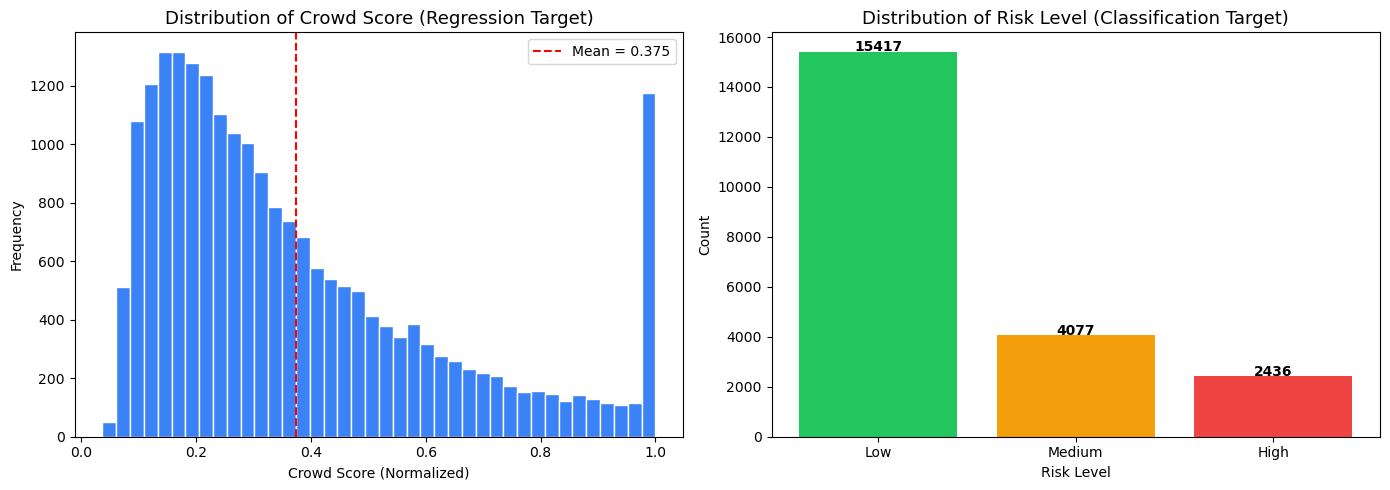

✅ Target distribution plot saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression target
axes[0].hist(df['crowd_score_normalized'], bins=40, color='#3b82f6', edgecolor='white')
axes[0].set_title('Distribution of Crowd Score (Regression Target)', fontsize=13)
axes[0].set_xlabel('Crowd Score (Normalized)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['crowd_score_normalized'].mean(), color='red',
                linestyle='--', label=f"Mean = {df['crowd_score_normalized'].mean():.3f}")
axes[0].legend()

# Classification target
risk_counts = df['risk_level'].value_counts()
axes[1].bar(risk_counts.index, risk_counts.values,
            color=['#22c55e', '#f59e0b', '#ef4444', '#7c3aed'][:len(risk_counts)])
axes[1].set_title('Distribution of Risk Level (Classification Target)', fontsize=13)
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Count')
for i, (label, val) in enumerate(risk_counts.items()):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/eda_target_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Target distribution plot saved")

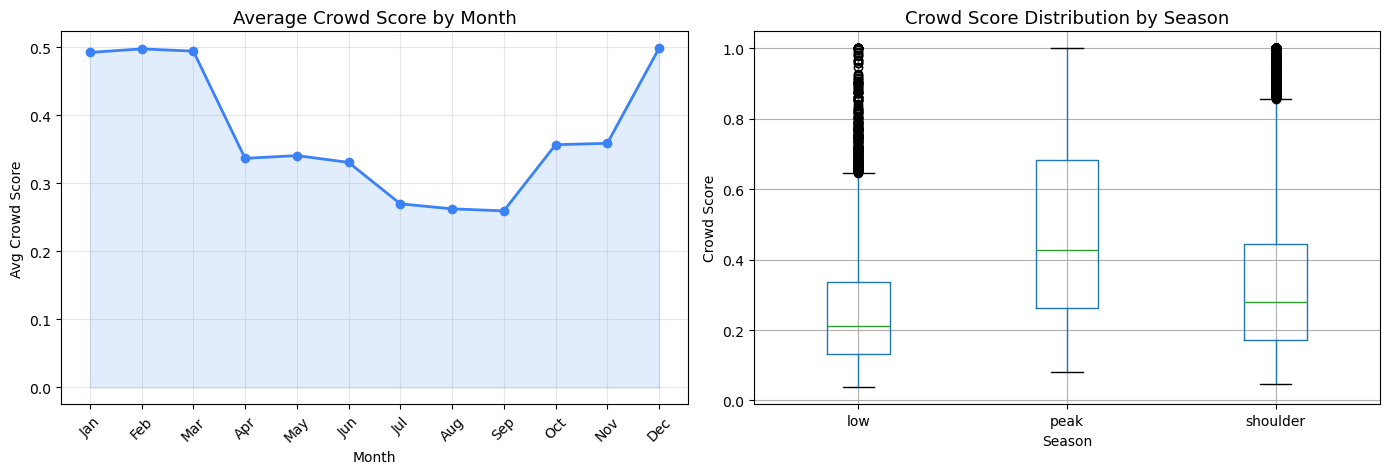

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly average crowd score
monthly = df.groupby('month')['crowd_score_normalized'].mean()
axes[0].plot(monthly.index, monthly.values, marker='o', color='#3b82f6', linewidth=2)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color='#3b82f6')
axes[0].set_title('Average Crowd Score by Month', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Crowd Score')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].grid(True, alpha=0.3)

# Season boxplot
df.boxplot(column='crowd_score_normalized', by='season', ax=axes[1])
axes[1].set_title('Crowd Score Distribution by Season', fontsize=13)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Crowd Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig("outputs/eda_seasonal_trends.png", dpi=150, bbox_inches='tight')
plt.show()

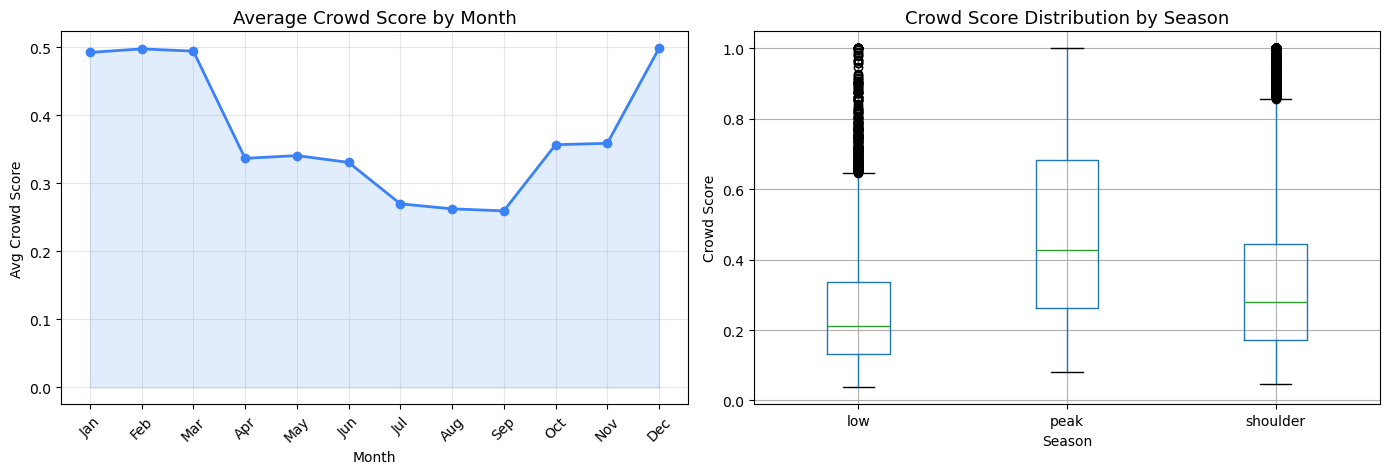

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly average crowd score
monthly = df.groupby('month')['crowd_score_normalized'].mean()
axes[0].plot(monthly.index, monthly.values, marker='o', color='#3b82f6', linewidth=2)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color='#3b82f6')
axes[0].set_title('Average Crowd Score by Month', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Crowd Score')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].grid(True, alpha=0.3)

# Season boxplot
df.boxplot(column='crowd_score_normalized', by='season', ax=axes[1])
axes[1].set_title('Crowd Score Distribution by Season', fontsize=13)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Crowd Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig("outputs/eda_seasonal_trends.png", dpi=150, bbox_inches='tight')
plt.show()

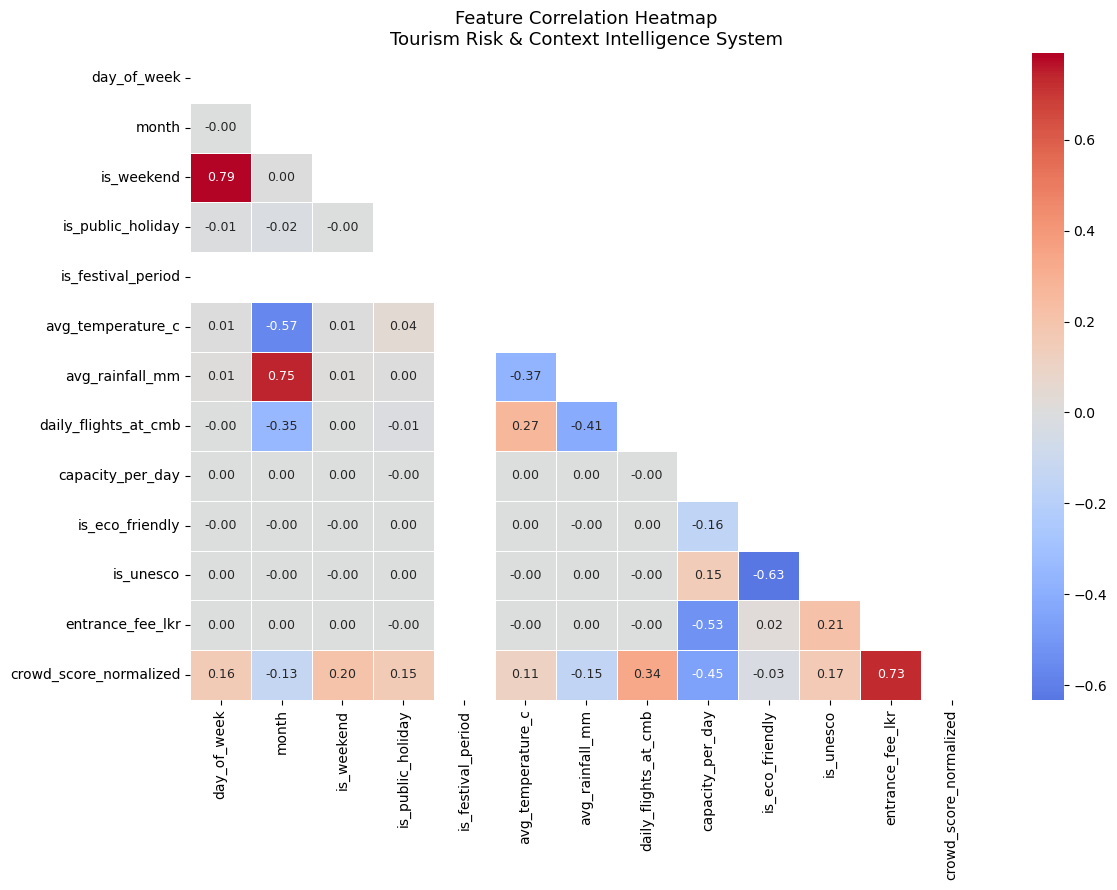

✅ Heatmap saved


In [18]:
FEATURES = [
    'day_of_week', 'month', 'is_weekend', 'is_public_holiday',
    'is_festival_period', 'avg_temperature_c', 'avg_rainfall_mm',
    'daily_flights_at_cmb', 'capacity_per_day', 'is_eco_friendly',
    'is_unesco', 'entrance_fee_lkr', 'crowd_score_normalized'
]
available_for_corr = [f for f in FEATURES if f in df.columns]

plt.figure(figsize=(12, 9))
corr_matrix = df[available_for_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap\nTourism Risk & Context Intelligence System', fontsize=13)
plt.tight_layout()
plt.savefig("outputs/eda_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved")

## Section 3 — Data Preprocessing & Encoding
Label encoding categorical columns: category, season, district, risk_level.

In [19]:
le_category = LabelEncoder()
le_season    = LabelEncoder()
le_district  = LabelEncoder()
le_risk      = LabelEncoder()

df['category_encoded'] = le_category.fit_transform(df['category'])
df['season_encoded']   = le_season.fit_transform(df['season'])
df['district_encoded'] = le_district.fit_transform(df['district'])
df['risk_encoded']     = le_risk.fit_transform(df['risk_level'])

print("✅ Encoding complete")
print(f"\n  Category classes : {list(le_category.classes_)}")
print(f"  Season classes   : {list(le_season.classes_)}")
print(f"  District classes : {list(le_district.classes_)}")
print(f"  Risk classes     : {list(le_risk.classes_)}")

✅ Encoding complete

  Category classes : ['Beach', 'Heritage', 'Nature', 'Religious']
  Season classes   : ['low', 'peak', 'shoulder']
  District classes : ['Ampara', 'Anuradhapura', 'Badulla', 'Colombo', 'Galle', 'Hambantota', 'Kandy', 'Kegalle', 'Matale', 'Matara', 'Nuwara Eliya', 'Polonnaruwa', 'Puttalam', 'Ratnapura', 'Trincomalee']
  Risk classes     : ['High', 'Low', 'Medium']


## Section 4 — Feature Engineering
Selecting the 15 features used for model training, including the novelty feature `daily_flights_at_cmb`.

In [20]:
FEATURES = [
    'day_of_week', 'month', 'is_weekend', 'is_public_holiday',
    'is_festival_period', 'avg_temperature_c', 'avg_rainfall_mm',
    'daily_flights_at_cmb', 'capacity_per_day', 'category_encoded',
    'season_encoded', 'district_encoded', 'is_eco_friendly',
    'is_unesco', 'entrance_fee_lkr'
]

available = [f for f in FEATURES if f in df.columns]
missing   = [f for f in FEATURES if f not in df.columns]

X       = df[available]
y_score = df['crowd_score_normalized']
y_risk  = df['risk_encoded']

print(f"✅ Feature matrix shape : {X.shape}")
print(f"   Features available   : {len(available)}")
if missing:
    print(f"⚠️  Features missing     : {missing}")

print(f"\n   Regression target  (y_score) : {y_score.shape}  —  min={y_score.min():.3f}  max={y_score.max():.3f}")
print(f"   Classification target (y_risk) : {y_risk.shape}  —  classes={list(le_risk.classes_)}")

✅ Feature matrix shape : (21930, 15)
   Features available   : 15

   Regression target  (y_score) : (21930,)  —  min=0.037  max=1.000
   Classification target (y_risk) : (21930,)  —  classes=['High', 'Low', 'Medium']


## Section 5 — Train / Test Split & Baseline
80/20 split with random_state=42. Baseline model always predicts the training mean.

In [21]:
X_train, X_test, y_score_train, y_score_test = train_test_split(
    X, y_score, test_size=0.2, random_state=42)
_, _, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42)

print(f"  Training set : {len(X_train)} records ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set     : {len(X_test)} records  ({len(X_test)/len(X)*100:.0f}%)")

# Baseline
baseline_pred = np.full(len(y_score_test), y_score_train.mean())
baseline_mae  = mean_absolute_error(y_score_test, baseline_pred)
baseline_r2   = r2_score(y_score_test, baseline_pred)

print(f"\n  Baseline always predicts mean : {y_score_train.mean():.4f}")
print(f"  Baseline MAE                  : {baseline_mae:.4f}")
print(f"  Baseline R²                   : {baseline_r2:.4f}")

  Training set : 17544 records (80%)
  Test set     : 4386 records  (20%)

  Baseline always predicts mean : 0.3757
  Baseline MAE                  : 0.2014
  Baseline R²                   : -0.0004


## Section 6 — Model Training (Random Forest)
Training Random Forest Regressor with initial parameters before tuning.

In [22]:
rf_regressor = RandomForestRegressor(
    n_estimators=100, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42, n_jobs=-1)

rf_regressor.fit(X_train, y_score_train)
y_pred_score = rf_regressor.predict(X_test)

mae = mean_absolute_error(y_score_test, y_pred_score)
r2  = r2_score(y_score_test, y_pred_score)

print("=== INITIAL REGRESSION RESULTS ===")
print(f"  MAE : {mae:.4f}  (target ≤ 0.25)  {'✅ PASSED' if mae <= 0.25 else '❌ FAILED'}")
print(f"  R²  : {r2:.4f}  (target ≥ 0.70)  {'✅ PASSED' if r2  >= 0.70 else '❌ FAILED'}")
print(f"\n  Improvement over baseline:")
print(f"  MAE improved : {((baseline_mae - mae) / baseline_mae * 100):.1f}%")

=== INITIAL REGRESSION RESULTS ===
  MAE : 0.0441  (target ≤ 0.25)  ✅ PASSED
  R²  : 0.9353  (target ≥ 0.70)  ✅ PASSED

  Improvement over baseline:
  MAE improved : 78.1%


## Section 7 — Cross Validation
5-fold cross validation to confirm the model generalises and is not overfitting to the test split.

  CV MAE : 0.0461  (+/- 0.0042)
  CV R²  : 0.9222  (+/- 0.0062)

  Individual fold MAE scores:
    Fold 1 : 0.0513
    Fold 2 : 0.0403
    Fold 3 : 0.0506
    Fold 4 : 0.0448
    Fold 5 : 0.0435

  Model is ✅ STABLE across folds


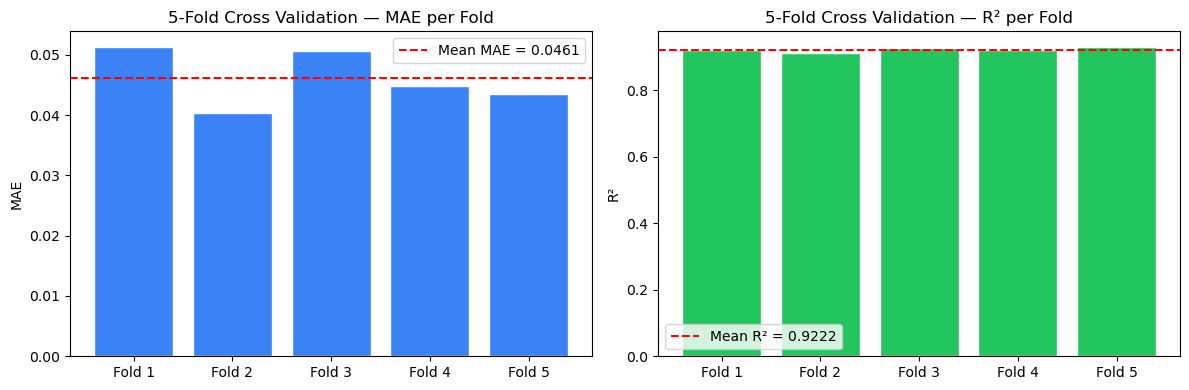

In [23]:
cv_mae_scores = cross_val_score(rf_regressor, X, y_score,
                                cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_r2_scores  = cross_val_score(rf_regressor, X, y_score,
                                cv=5, scoring='r2', n_jobs=-1)

cv_mae     = -cv_mae_scores.mean()
cv_mae_std =  cv_mae_scores.std()
cv_r2      =  cv_r2_scores.mean()
cv_r2_std  =  cv_r2_scores.std()

print(f"  CV MAE : {cv_mae:.4f}  (+/- {cv_mae_std:.4f})")
print(f"  CV R²  : {cv_r2:.4f}  (+/- {cv_r2_std:.4f})")
print(f"\n  Individual fold MAE scores:")
for i, s in enumerate(-cv_mae_scores):
    print(f"    Fold {i+1} : {s:.4f}")
print(f"\n  Model is {'✅ STABLE' if cv_mae_std < 0.05 else '⚠️  VARIABLE'} across folds")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

folds = [f"Fold {i+1}" for i in range(5)]
axes[0].bar(folds, -cv_mae_scores, color='#3b82f6', edgecolor='white')
axes[0].axhline(cv_mae, color='red', linestyle='--', label=f'Mean MAE = {cv_mae:.4f}')
axes[0].set_title('5-Fold Cross Validation — MAE per Fold')
axes[0].set_ylabel('MAE')
axes[0].legend()

axes[1].bar(folds, cv_r2_scores, color='#22c55e', edgecolor='white')
axes[1].axhline(cv_r2, color='red', linestyle='--', label=f'Mean R² = {cv_r2:.4f}')
axes[1].set_title('5-Fold Cross Validation — R² per Fold')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/cv_results.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Hyperparameter Tuning (Grid Search)
Grid search over n_estimators, max_depth, and min_samples_split with 3-fold CV.

In [25]:
param_grid = {
    'n_estimators':    [50, 100, 150],
    'max_depth':       [8, 10, 12],
    'min_samples_split': [3, 5, 7]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_score_train)

best_params = grid_search.best_params_
print("✅ Grid Search complete")
print(f"\n  Best hyperparameters:")
for k, v in best_params.items():
    print(f"    {k:25s}: {v}")
print(f"\n  Best CV MAE : {-grid_search.best_score_:.4f}")

✅ Grid Search complete

  Best hyperparameters:
    max_depth                : 12
    min_samples_split        : 7
    n_estimators             : 150

  Best CV MAE : 0.0442


In [26]:
rf_regressor = RandomForestRegressor(
    n_estimators    = best_params['n_estimators'],
    max_depth       = best_params['max_depth'],
    min_samples_split = best_params['min_samples_split'],
    random_state=42, n_jobs=-1)
rf_regressor.fit(X_train, y_score_train)

y_pred_score       = rf_regressor.predict(X_test)
y_pred_score_train = rf_regressor.predict(X_train)

mae       = mean_absolute_error(y_score_test,  y_pred_score)
r2        = r2_score(y_score_test,  y_pred_score)
train_mae = mean_absolute_error(y_score_train, y_pred_score_train)
train_r2  = r2_score(y_score_train, y_pred_score_train)

print("=== TUNED MODEL — REGRESSION RESULTS ===")
print(f"  Test  MAE : {mae:.4f}   (target ≤ 0.25)  {'✅ PASSED' if mae <= 0.25 else '❌ FAILED'}")
print(f"  Test  R²  : {r2:.4f}   (target ≥ 0.70)  {'✅ PASSED' if r2  >= 0.70 else '❌ FAILED'}")
print(f"\n  Train MAE : {train_mae:.4f}")
print(f"  Train R²  : {train_r2:.4f}")

=== TUNED MODEL — REGRESSION RESULTS ===
  Test  MAE : 0.0427   (target ≤ 0.25)  ✅ PASSED
  Test  R²  : 0.9372   (target ≥ 0.70)  ✅ PASSED

  Train MAE : 0.0361
  Train R²  : 0.9575


## Section 9 — Classification Model (Risk Level)
Random Forest Classifier trained to predict Low / Medium / High / Critical risk.

In [27]:
rf_classifier = RandomForestClassifier(
    n_estimators    = best_params['n_estimators'],
    max_depth       = best_params['max_depth'],
    min_samples_split = best_params['min_samples_split'],
    random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_risk_train)

y_pred_risk       = rf_classifier.predict(X_test)
y_pred_risk_train = rf_classifier.predict(X_train)

train_accuracy = accuracy_score(y_risk_train, y_pred_risk_train)
test_accuracy  = accuracy_score(y_risk_test,  y_pred_risk)

print(f"  Training Accuracy : {train_accuracy:.4f}")
print(f"  Test Accuracy     : {test_accuracy:.4f}")
print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_risk_test, y_pred_risk, target_names=le_risk.classes_))

  Training Accuracy : 0.9280
  Test Accuracy     : 0.9118

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        High       0.85      0.87      0.86       481
         Low       0.95      0.97      0.96      3123
      Medium       0.77      0.72      0.74       782

    accuracy                           0.91      4386
   macro avg       0.86      0.85      0.85      4386
weighted avg       0.91      0.91      0.91      4386



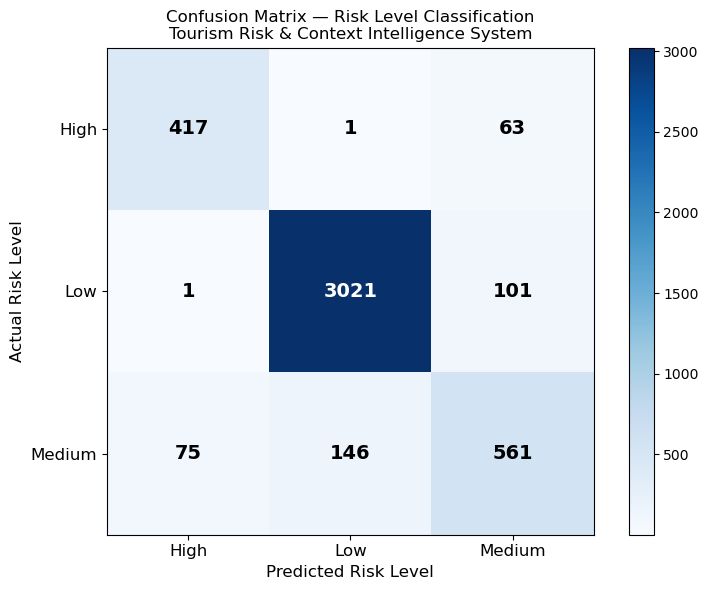

✅ Confusion matrix saved


In [28]:
cm = confusion_matrix(y_risk_test, y_pred_risk)
classes = le_risk.classes_

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(classes)));  ax.set_xticklabels(classes, fontsize=12)
ax.set_yticks(range(len(classes)));  ax.set_yticklabels(classes, fontsize=12)

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_xlabel('Predicted Risk Level', fontsize=12)
ax.set_ylabel('Actual Risk Level', fontsize=12)
ax.set_title('Confusion Matrix — Risk Level Classification\nTourism Risk & Context Intelligence System', fontsize=12)
plt.colorbar(im)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

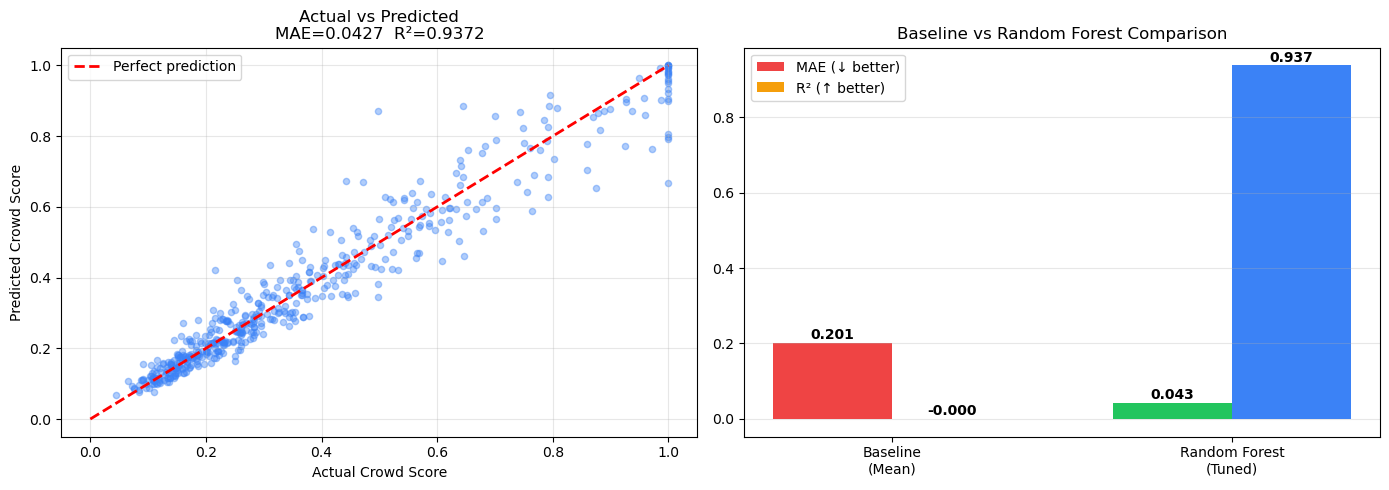

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_size = min(500, len(y_score_test))
idx = np.random.choice(len(y_score_test), sample_size, replace=False)

axes[0].scatter(y_score_test.iloc[idx], y_pred_score[idx],
                alpha=0.4, color='#3b82f6', s=20)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Crowd Score');  axes[0].set_ylabel('Predicted Crowd Score')
axes[0].set_title(f'Actual vs Predicted\nMAE={mae:.4f}  R²={r2:.4f}', fontsize=12)
axes[0].legend();  axes[0].grid(True, alpha=0.3)

models     = ['Baseline\n(Mean)', 'Random Forest\n(Tuned)']
mae_vals   = [baseline_mae, mae]
r2_vals    = [baseline_r2,  r2]
x = np.arange(2);  w = 0.35

b1 = axes[1].bar(x - w/2, mae_vals, w, label='MAE (↓ better)', color=['#ef4444','#22c55e'])
b2 = axes[1].bar(x + w/2, r2_vals,  w, label='R² (↑ better)',  color=['#f59e0b','#3b82f6'])
axes[1].set_xticks(x);  axes[1].set_xticklabels(models)
axes[1].set_title('Baseline vs Random Forest Comparison')
axes[1].legend();  axes[1].grid(True, alpha=0.3, axis='y')

for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 10 — Feature Importance
Gini-based feature importance from the tuned Random Forest Regressor. 
`daily_flights_at_cmb` is the novelty feature unique to this system.

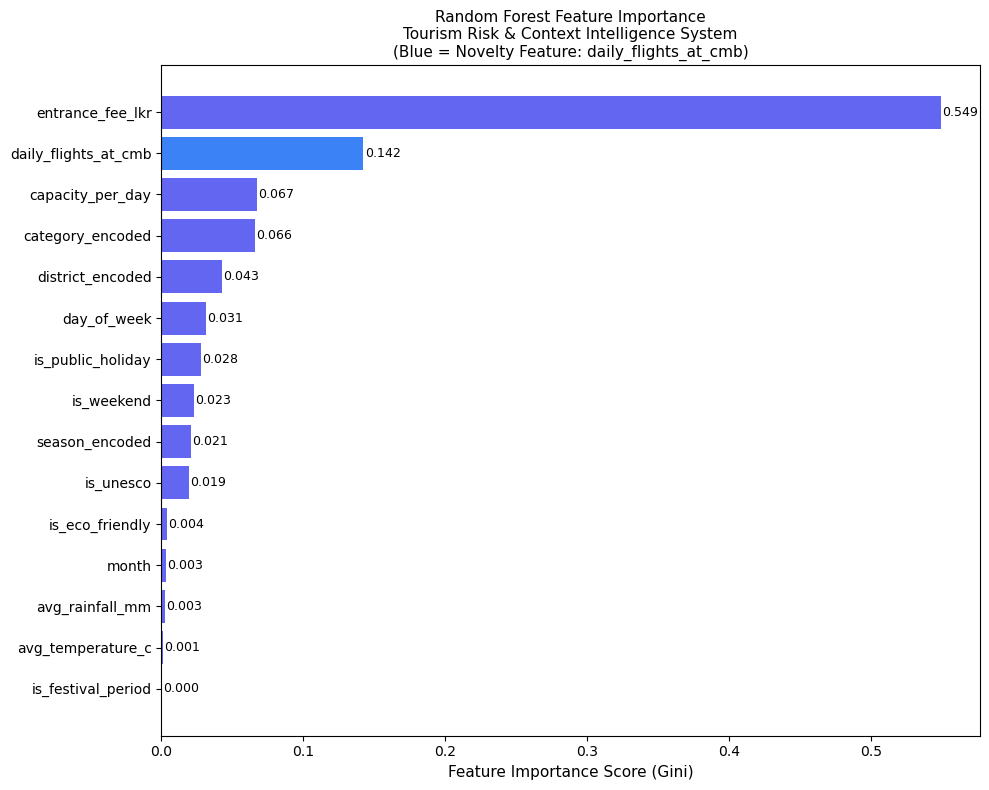

In [30]:
importance_df = pd.DataFrame({
    'feature':    available,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#3b82f6' if f == 'daily_flights_at_cmb' else '#6366f1'
          for f in importance_df['feature']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['feature'], importance_df['importance'], color=colors)
ax.set_xlabel('Feature Importance Score (Gini)', fontsize=11)
ax.set_title('Random Forest Feature Importance\nTourism Risk & Context Intelligence System\n(Blue = Novelty Feature: daily_flights_at_cmb)', fontsize=11)

for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 11 — SHAP Analysis
SHAP (SHapley Additive exPlanations) explains *why* the model makes each prediction.
This is explainability evidence required for the viva.

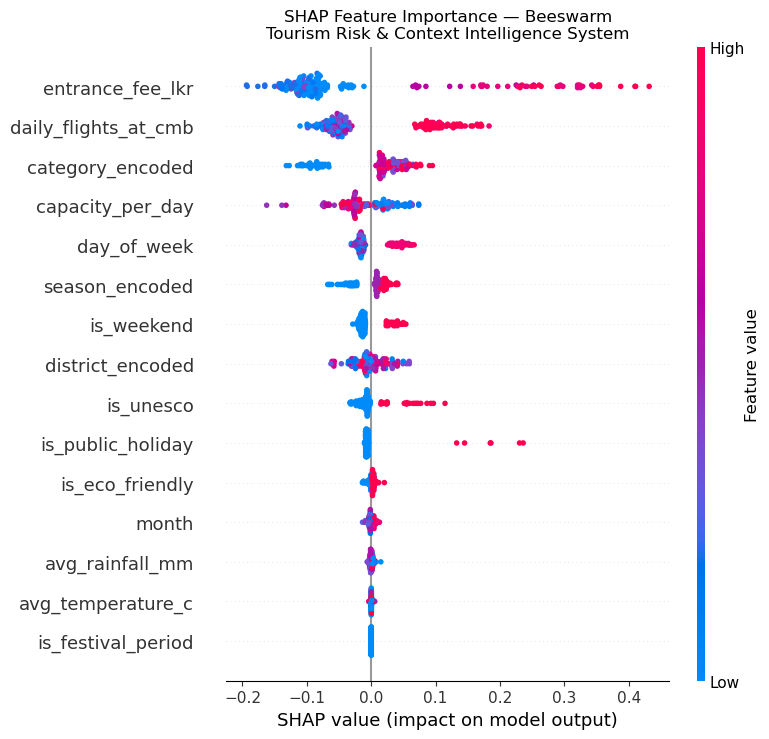

✅ SHAP summary plot saved


In [31]:
explainer    = shap.TreeExplainer(rf_regressor)
shap_sample  = X_test.iloc[:200]
shap_values  = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=available, show=False)
plt.title("SHAP Feature Importance — Beeswarm\nTourism Risk & Context Intelligence System", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved")

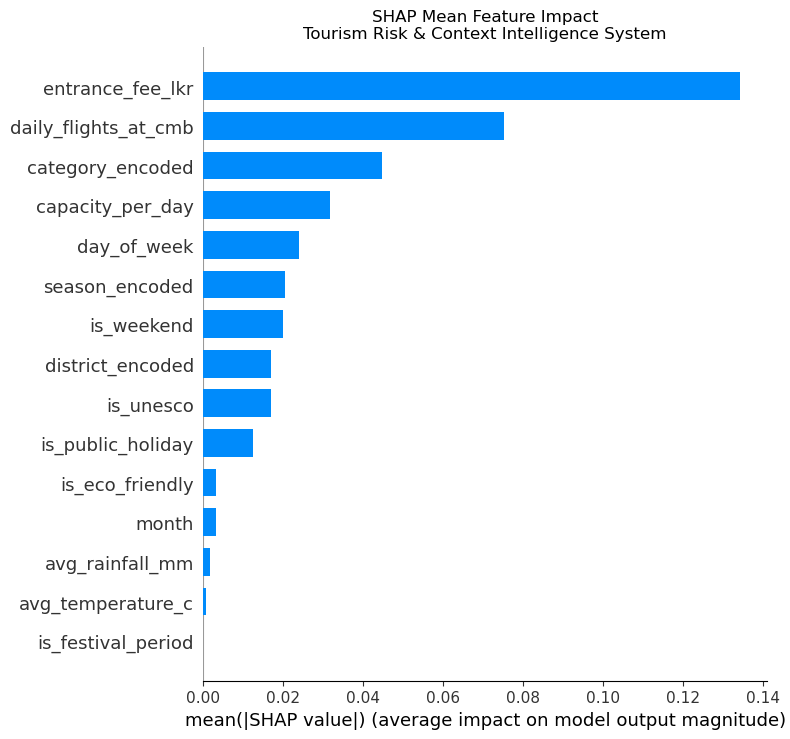

✅ SHAP bar plot saved


In [32]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, feature_names=available,
                  plot_type="bar", show=False)
plt.title("SHAP Mean Feature Impact\nTourism Risk & Context Intelligence System", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/shap_bar_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP bar plot saved")

In [33]:
with open("models/rf_regressor.pkl",  "wb") as f: pickle.dump(rf_regressor,  f)
with open("models/rf_classifier.pkl", "wb") as f: pickle.dump(rf_classifier, f)
with open("models/risk_encoder.pkl",  "wb") as f: pickle.dump(le_risk,       f)
with open("models/label_encoders.pkl","wb") as f:
    pickle.dump({'category': le_category, 'season': le_season, 'district': le_district}, f)

metrics = {
    "model_type": "Random Forest",
    "best_params": best_params,
    "train_records": len(X_train), "test_records": len(X_test),
    "features_used": len(available),
    "mae": round(mae, 4), "r2": round(r2, 4),
    "train_mae": round(train_mae, 4), "train_r2": round(train_r2, 4),
    "train_accuracy": round(train_accuracy, 4), "test_accuracy": round(test_accuracy, 4),
    "baseline_mae": round(baseline_mae, 4), "baseline_r2": round(baseline_r2, 4),
    "cv_mae": round(cv_mae, 4), "cv_mae_std": round(cv_mae_std, 4),
    "cv_r2": round(cv_r2, 4),  "cv_r2_std": round(cv_r2_std, 4),
    "mae_target": 0.25, "r2_target": 0.70,
    "mae_achieved": bool(mae <= 0.25), "r2_achieved": bool(r2 >= 0.70),
    "risk_classes": list(le_risk.classes_)
}
with open("models/model_metrics.json","w") as f: json.dump(metrics, f, indent=2)

print("✅ All models saved to models/")
print("✅ model_metrics.json saved")

✅ All models saved to models/
✅ model_metrics.json saved


## Section 12 — Final Summary

In [34]:
print("=" * 60)
print("  TOURISM RISK SYSTEM — PP1 FINAL SUMMARY")
print("=" * 60)
print(f"  Algorithm         : Random Forest")
print(f"  Training records  : {len(X_train)}")
print(f"  Test records      : {len(X_test)}")
print(f"  Features used     : {len(available)}")
print(f"  Best n_estimators : {best_params['n_estimators']}")
print(f"  Best max_depth    : {best_params['max_depth']}")
print(f"  Best min_samples  : {best_params['min_samples_split']}")
print()
print(f"  REGRESSION")
print(f"    Test  MAE  : {mae:.4f}   {'✅ PASSED' if mae <= 0.25 else '❌ FAILED'} (target ≤ 0.25)")
print(f"    Test  R²   : {r2:.4f}   {'✅ PASSED' if r2  >= 0.70 else '❌ FAILED'} (target ≥ 0.70)")
print(f"    Train MAE  : {train_mae:.4f}")
print(f"    Train R²   : {train_r2:.4f}")
print()
print(f"  CLASSIFICATION")
print(f"    Train Acc  : {train_accuracy:.4f}")
print(f"    Test  Acc  : {test_accuracy:.4f}")
print()
print(f"  CROSS VALIDATION")
print(f"    CV MAE     : {cv_mae:.4f}  +/- {cv_mae_std:.4f}")
print(f"    CV R²      : {cv_r2:.4f}  +/- {cv_r2_std:.4f}")
print()
print(f"  BASELINE IMPROVEMENT")
print(f"    Baseline MAE : {baseline_mae:.4f}")
print(f"    RF MAE       : {mae:.4f}")
print(f"    Improvement  : {((baseline_mae - mae) / baseline_mae * 100):.1f}%")
print()
print(f"  OUTPUTS SAVED")
print(f"    outputs/confusion_matrix.png")
print(f"    outputs/actual_vs_predicted.png")
print(f"    outputs/feature_importance.png")
print(f"    outputs/shap_summary_plot.png")
print(f"    outputs/shap_bar_plot.png")
print(f"    outputs/eda_target_distributions.png")
print(f"    outputs/eda_seasonal_trends.png")
print(f"    outputs/eda_correlation_heatmap.png")
print(f"    outputs/cv_results.png")
print("=" * 60)

  TOURISM RISK SYSTEM — PP1 FINAL SUMMARY
  Algorithm         : Random Forest
  Training records  : 17544
  Test records      : 4386
  Features used     : 15
  Best n_estimators : 150
  Best max_depth    : 12
  Best min_samples  : 7

  REGRESSION
    Test  MAE  : 0.0427   ✅ PASSED (target ≤ 0.25)
    Test  R²   : 0.9372   ✅ PASSED (target ≥ 0.70)
    Train MAE  : 0.0361
    Train R²   : 0.9575

  CLASSIFICATION
    Train Acc  : 0.9280
    Test  Acc  : 0.9118

  CROSS VALIDATION
    CV MAE     : 0.0461  +/- 0.0042
    CV R²      : 0.9222  +/- 0.0062

  BASELINE IMPROVEMENT
    Baseline MAE : 0.2014
    RF MAE       : 0.0427
    Improvement  : 78.8%

  OUTPUTS SAVED
    outputs/confusion_matrix.png
    outputs/actual_vs_predicted.png
    outputs/feature_importance.png
    outputs/shap_summary_plot.png
    outputs/shap_bar_plot.png
    outputs/eda_target_distributions.png
    outputs/eda_seasonal_trends.png
    outputs/eda_correlation_heatmap.png
    outputs/cv_results.png
